In [1]:
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

# ── Zomato CSV ──────────────────────────────────
df_zomato = pd.read_csv(
    r'D:\hiirupak\archive\zomato.csv', 
    encoding='latin-1'
)

print("✅ ZOMATO CSV LOADED")
print(f"Shape: {df_zomato.shape}")
print(f"\nColumns:\n{df_zomato.columns.tolist()}")
print(f"\nSample Data:")
print(df_zomato.head(3))
print(f"\nNull Values:\n{df_zomato.isnull().sum()}")

✅ ZOMATO CSV LOADED
Shape: (9551, 21)

Columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Sample Data:
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   

                                     Locality  \
0   Century City M

In [2]:
# ── JSON File Structure Check ───────────────────
with open(r'D:\hiirupak\archive\file1.json', 
          'r', encoding='utf-8') as f:
    sample = json.load(f)

print("✅ JSON FILE1 LOADED")
print(f"Type: {type(sample)}")

if isinstance(sample, list):
    print(f"Total records: {len(sample)}")
    print(f"\nFirst record keys: {sample[0].keys()}")
    print(f"\nFirst record sample:\n{sample[0]}")
elif isinstance(sample, dict):
    print(f"Keys: {sample.keys()}")
    # Nested structure check
    first_key = list(sample.keys())[0]
    print(f"\nFirst key '{first_key}' value type: {type(sample[first_key])}")
    print(f"Sample: {sample[first_key]}")

✅ JSON FILE1 LOADED
Type: <class 'list'>
Total records: 479

First record keys: dict_keys(['results_found', 'restaurants', 'results_shown', 'results_start'])

First record sample:
{'results_found': 17151, 'restaurants': [{'restaurant': {'has_online_delivery': 1, 'photos_url': 'https://www.zomato.com/HauzKhasSocial/photos?utm_source=api_basic_user&utm_medium=api&utm_campaign=v2.1#tabtop', 'url': 'https://www.zomato.com/HauzKhasSocial?utm_source=api_basic_user&utm_medium=api&utm_campaign=v2.1', 'price_range': 3, 'apikey': 'b90e6a8c738410315a20c449fe2eb1b1', 'user_rating': {'rating_text': 'Very Good', 'rating_color': '5BA829', 'votes': '7931', 'aggregate_rating': '4.3'}, 'R': {'res_id': 308322}, 'name': 'Hauz Khas Social', 'cuisines': 'Continental, American, Asian, North Indian', 'is_delivering_now': 0, 'deeplink': 'zomato://restaurant/308322', 'menu_url': 'https://www.zomato.com/HauzKhasSocial/menu?utm_source=api_basic_user&utm_medium=api&utm_campaign=v2.1&openSwipeBox=menu&showMinimal=1

In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn textblob wordcloud nltk openpyxl

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 10.1 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 14.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 15.9 MB/s  0:00:00
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 22.5 MB/s  0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 20.7 MB/s  0:00:00

   ----------------------------------------  0/10 [tqdm]
   ----------------------------------------  0/10 [tqdm]
   ---- -----------------------------------  1/10 [threadpoolctl]
   -------- -------------------------------  2/10 [regex]
   ------------ ---------------------------  3/10 [narwhals]
   ------------ ---------------------------  3/10 [narwhals]
   ------------ ---------------------------  3/10 


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ============================================================
# RESTAURANT REVIEW SENTIMENT ANALYSIS
# Zomato Dataset | Rupak Kumar | IIT Kanpur
# ============================================================

# ── CELL 1: IMPORTS & SETUP ─────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, 
                              classification_report,
                              confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ All libraries loaded successfully!")
print("━" * 50)

✅ All libraries loaded successfully!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [2]:
# ── CELL 2: DATA LOADING ────────────────────────────────────

# Load main Zomato CSV
df_raw = pd.read_csv(
    r'D:\hiirupak\archive\zomato.csv',
    encoding='latin-1'
)

# Load Country Codes
country_df = pd.read_excel(
    r'D:\hiirupak\archive\Country-Code.xlsx'
)

print("✅ Files Loaded!")
print(f"Zomato Shape   : {df_raw.shape}")
print(f"Country Shape  : {country_df.shape}")
print(f"\nZomato Columns :\n{df_raw.columns.tolist()}")
print(f"\nCountry Columns:\n{country_df.columns.tolist()}")
print(f"\nZomato Sample  :")
df_raw.head(3)

✅ Files Loaded!
Zomato Shape   : (9551, 21)
Country Shape  : (15, 2)

Zomato Columns :
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Country Columns:
['Country Code', 'Country']

Zomato Sample  :


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


In [3]:
# ── CELL 3: EXTRACT REVIEWS FROM reviews_list ───────────────
# (Run this IF reviews_list column exists in your CSV)

# First check if reviews_list exists
if 'reviews_list' in df_raw.columns:
    print("✅ reviews_list column found!")
    print(f"\nSample review entry:")
    print(df_raw['reviews_list'].iloc[5])
    
    # Parse reviews from string format
    # Zomato format: [('Rated X.0', 'review text'), ...]
    
    reviews_extracted = []
    
    for idx, row in df_raw.iterrows():
        try:
            reviews_str = str(row['reviews_list'])
            
            # Find all (rating, review) tuples
            pattern = r"Rated\s+(\d+\.?\d*)',\s+'([^']+)'"
            matches = re.findall(pattern, reviews_str)
            
            if matches:
                for rating_str, review_text in matches:
                    reviews_extracted.append({
                        'restaurant_name' : row.get('name', 'Unknown'),
                        'location'        : row.get('location', 'Unknown'),
                        'cuisine'         : row.get('cuisines', 'Unknown'),
                        'review_text'     : review_text.strip(),
                        'rating'          : float(rating_str),
                        'restaurant_rate' : str(row.get('rate', '0')),
                        'votes'           : row.get('votes', 0),
                        'cost_for_two'    : row.get(
                                           'approx_cost(for two people)', 0),
                        'online_order'    : row.get('online_order', 'No'),
                        'book_table'      : row.get('book_table', 'No')
                    })
            else:
                # Try alternate extraction
                reviews_alt = re.findall(
                    r"'([^']{20,})'", reviews_str)
                for rev in reviews_alt:
                    if any(c.isalpha() for c in rev):
                        reviews_extracted.append({
                            'restaurant_name' : row.get('name', 'Unknown'),
                            'location'        : row.get('location', 'Unknown'),
                            'cuisine'         : row.get('cuisines', 'Unknown'),
                            'review_text'     : rev.strip(),
                            'rating'          : float(str(
                                               row.get('rate','3.0')
                                               ).replace('/5','').strip()) 
                                               if row.get('rate') else 3.0,
                            'votes'           : row.get('votes', 0),
                            'cost_for_two'    : row.get(
                                               'approx_cost(for two people)', 0),
                            'online_order'    : row.get('online_order', 'No'),
                            'book_table'      : row.get('book_table', 'No')
                        })
        except Exception as e:
            continue
    
    df_reviews = pd.DataFrame(reviews_extracted)
    print(f"\n✅ Reviews Extracted: {len(df_reviews):,}")
    print(f"Columns: {df_reviews.columns.tolist()}")
    print(df_reviews.head(3))

else:
    print("⚠️ reviews_list NOT found")
    print("Available columns:", df_raw.columns.tolist())
    print("\n→ Will use JSON files for reviews")

⚠️ reviews_list NOT found
Available columns: ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

→ Will use JSON files for reviews


In [6]:
import json

with open(r'D:\hiirupak\archive\file1.json', 
          'r', encoding='utf-8') as f:
    data = json.load(f)

# ── Step 1: Top level type ──────────────────────
print("TYPE:", type(data))
print("━" * 50)

# ── Step 2: Agar list hai ───────────────────────
if isinstance(data, list):
    print(f"LIST LENGTH: {len(data)}")
    print(f"\nFirst Element Type: {type(data[0])}")
    print(f"\nFirst Element:")
    print(data[0])
    print(f"\nFirst Element Keys (if dict):")
    if isinstance(data[0], dict):
        print(data[0].keys())
        # Nested check
        for key in data[0].keys():
            print(f"\n  Key: '{key}'")
            print(f"  Value type: {type(data[0][key])}")
            print(f"  Value preview: {str(data[0][key])[:200]}")

# ── Step 3: Agar dict hai ───────────────────────
elif isinstance(data, dict):
    print(f"DICT KEYS (first 5): {list(data.keys())[:5]}")
    first_key = list(data.keys())[0]
    print(f"\nFirst Key: '{first_key}'")
    print(f"First Value Type: {type(data[first_key])}")
    print(f"First Value Preview:")
    print(str(data[first_key])[:500])
    
    # If nested dict
    if isinstance(data[first_key], dict):
        print(f"\nNested Keys: {data[first_key].keys()}")
    elif isinstance(data[first_key], list):
        print(f"\nList Length: {len(data[first_key])}")
        print(f"First item: {data[first_key][0]}")

TYPE: <class 'list'>
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LIST LENGTH: 479

First Element Type: <class 'dict'>

First Element:
{'results_found': 17151, 'restaurants': [{'restaurant': {'has_online_delivery': 1, 'photos_url': 'https://www.zomato.com/HauzKhasSocial/photos?utm_source=api_basic_user&utm_medium=api&utm_campaign=v2.1#tabtop', 'url': 'https://www.zomato.com/HauzKhasSocial?utm_source=api_basic_user&utm_medium=api&utm_campaign=v2.1', 'price_range': 3, 'apikey': 'b90e6a8c738410315a20c449fe2eb1b1', 'user_rating': {'rating_text': 'Very Good', 'rating_color': '5BA829', 'votes': '7931', 'aggregate_rating': '4.3'}, 'R': {'res_id': 308322}, 'name': 'Hauz Khas Social', 'cuisines': 'Continental, American, Asian, North Indian', 'is_delivering_now': 0, 'deeplink': 'zomato://restaurant/308322', 'menu_url': 'https://www.zomato.com/HauzKhasSocial/menu?utm_source=api_basic_user&utm_medium=api&utm_campaign=v2.1&openSwipeBox=menu&showMinimal=1#tabtop', 'average_cost_for_two': 1600,

In [7]:
import pandas as pd

df = pd.read_csv(
    r'D:\hiirupak\archive\zomato.csv',
    encoding='latin-1'
)

print("SHAPE:", df.shape)
print("\nCOLUMNS:", df.columns.tolist())
print("\nSAMPLE:")
df.head(2)

SHAPE: (9551, 21)

COLUMNS: ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

SAMPLE:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591


In [4]:
# ── CELL 4: IF reviews_list NOT FOUND — USE JSON FILES ──────
# (Run this if Cell 3 shows reviews_list not found)

def load_json_reviews(filepath):
    """Load reviews from Zomato JSON files"""
    reviews = []
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Handle different JSON structures
        if isinstance(data, list):
            for item in data:
                # Structure 1: Direct review objects
                if isinstance(item, dict):
                    # Try to extract review info
                    review = {}
                    
                    # Common key patterns in Zomato JSON
                    for key in item.keys():
                        key_lower = key.lower()
                        if 'review' in key_lower or 'comment' in key_lower:
                            review['review_text'] = str(item[key])
                        elif 'rating' in key_lower or 'rate' in key_lower:
                            try:
                                review['rating'] = float(str(
                                    item[key]).replace('/5','').strip())
                            except:
                                review['rating'] = 3.0
                        elif 'name' in key_lower and 'restaurant' in key_lower:
                            review['restaurant_name'] = str(item[key])
                    
                    if 'review_text' in review and len(
                            review.get('review_text','')) > 10:
                        reviews.append(review)
                        
        elif isinstance(data, dict):
            # Nested structure
            for key, value in data.items():
                if isinstance(value, list):
                    for item in value:
                        if isinstance(item, dict):
                            review = {'restaurant_name': key}
                            for k, v in item.items():
                                if any(x in k.lower() for x in 
                                      ['review', 'comment', 'text']):
                                    review['review_text'] = str(v)
                                elif any(x in k.lower() for x in 
                                        ['rating', 'rate', 'score']):
                                    try:
                                        review['rating'] = float(
                                            str(v).replace('/5','').strip())
                                    except:
                                        review['rating'] = 3.0
                            if 'review_text' in review:
                                reviews.append(review)
    except Exception as e:
        print(f"Error in {filepath}: {e}")
    
    return reviews

# Load all 5 JSON files
print("⏳ Loading JSON files...")
all_reviews = []

for i in range(1, 6):
    filepath = rf'D:\hiirupak\archive\file{i}.json'
    reviews = load_json_reviews(filepath)
    all_reviews.extend(reviews)
    print(f"  file{i}.json → {len(reviews):,} reviews loaded")

df_reviews = pd.DataFrame(all_reviews)
print(f"\n✅ Total Reviews Loaded: {len(df_reviews):,}")
print(f"Columns: {df_reviews.columns.tolist()}")
df_reviews.head()

⏳ Loading JSON files...
  file1.json → 0 reviews loaded
  file2.json → 0 reviews loaded
  file3.json → 0 reviews loaded
  file4.json → 0 reviews loaded
  file5.json → 0 reviews loaded

✅ Total Reviews Loaded: 0
Columns: []


""


In [5]:
# ── CELL 5: DATA CLEANING ────────────────────────────────────

print("📋 BEFORE CLEANING:")
print(f"Total rows      : {len(df_reviews):,}")
print(f"Missing values  :\n{df_reviews.isnull().sum()}")

# Step 1: Drop duplicates
df_reviews = df_reviews.drop_duplicates(subset=['review_text'])
print(f"\nAfter dedup     : {len(df_reviews):,}")

# Step 2: Drop nulls in critical columns
df_reviews = df_reviews.dropna(subset=['review_text'])
print(f"After null drop : {len(df_reviews):,}")

# Step 3: Remove very short reviews (< 5 words)
df_reviews['word_count'] = df_reviews['review_text'].apply(
    lambda x: len(str(x).split()))
df_reviews = df_reviews[df_reviews['word_count'] >= 5]
print(f"After length filter: {len(df_reviews):,}")

# Step 4: Clean rating column
if 'rating' not in df_reviews.columns:
    # Use TextBlob polarity as proxy rating
    df_reviews['rating'] = df_reviews['review_text'].apply(
        lambda x: (TextBlob(str(x)).sentiment.polarity + 1) * 2.5)

df_reviews['rating'] = pd.to_numeric(
    df_reviews['rating'], errors='coerce').fillna(3.0)

# Step 5: Clip ratings to 1-5 scale
df_reviews['rating'] = df_reviews['rating'].clip(1, 5)

# Step 6: Create Sentiment Labels
def assign_sentiment(rating):
    if rating >= 4.0:
        return 'Positive'
    elif rating >= 3.0:
        return 'Neutral'
    else:
        return 'Negative'

df_reviews['sentiment'] = df_reviews['rating'].apply(assign_sentiment)

# Step 7: Review length features
df_reviews['review_length'] = df_reviews['review_text'].apply(
    lambda x: len(str(x).split()))
df_reviews['char_count'] = df_reviews['review_text'].apply(
    lambda x: len(str(x)))

print(f"\n📊 AFTER CLEANING:")
print(f"Total Reviews   : {len(df_reviews):,}")
print(f"\nSentiment Distribution:")
print(df_reviews['sentiment'].value_counts())
print(f"\nSentiment %:")
print(df_reviews['sentiment'].value_counts(normalize=True)
      .mul(100).round(1).astype(str) + '%')

df_reviews.head()

📋 BEFORE CLEANING:
Total rows      : 0
Missing values  :
Series([], dtype: float64)

After dedup     : 0


KeyError: ['review_text']

In [8]:
# ============================================================
# ZOMATO RESTAURANT ANALYTICS & RATING INTELLIGENCE
# Rupak Kumar | IIT Kanpur | Data Analyst Project
# Dataset: 9,500+ Restaurants | 15 Countries | 141 Cities
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)
from sklearn.tree import DecisionTreeClassifier
from scipy import stats

plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#161b22'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#21262d'
plt.rcParams['grid.alpha']       = 0.5

print("✅ All Libraries Loaded!")
print("━" * 50)

✅ All Libraries Loaded!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [9]:
# ── LOAD ZOMATO CSV ──────────────────────────────
df = pd.read_csv(
    r'D:\hiirupak\archive\zomato.csv',
    encoding='latin-1'
)

# Load Country Codes
country = pd.read_excel(
    r'D:\hiirupak\archive\Country-Code.xlsx'
)

# Merge country names
df = df.merge(country, on='Country Code', how='left')

print("✅ CSV Loaded!")
print(f"Shape          : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print(f"Countries      : {df['Country Code'].nunique()}")
print(f"Cities         : {df['City'].nunique()}")
print(f"\nNull Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

✅ CSV Loaded!
Shape          : (9551, 22)
Columns        : ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes', 'Country']
Countries      : 15
Cities         : 141

Null Values:
Cuisines    9
dtype: int64


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines


In [10]:
# ── LOAD ALL 5 JSON FILES ────────────────────────
def extract_from_json(filepath):
    restaurants = []
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Structure: list of pages
        # Each page → {'restaurants': [...], ...}
        for page in data:
            rest_list = page.get('restaurants', [])
            for item in rest_list:
                r = item.get('restaurant', {})
                
                # Extract fields
                rating_info = r.get('user_rating', {})
                location    = r.get('location', {})
                
                restaurants.append({
                    'name'              : r.get('name', ''),
                    'cuisines'          : r.get('cuisines', ''),
                    'avg_cost_for_two'  : r.get('average_cost_for_two', 0),
                    'has_online_delivery': r.get('has_online_delivery', 0),
                    'has_table_booking' : r.get('has_table_booking', 0),
                    'price_range'       : r.get('price_range', 0),
                    'aggregate_rating'  : float(
                        rating_info.get('aggregate_rating', 0) or 0),
                    'rating_text'       : rating_info.get('rating_text', ''),
                    'votes'             : int(
                        rating_info.get('votes', 0) or 0),
                    'city'              : location.get('city', ''),
                    'locality'          : location.get('locality', ''),
                    'latitude'          : location.get('latitude', 0),
                    'longitude'         : location.get('longitude', 0),
                    'currency'          : r.get('currency', '')
                })
    except Exception as e:
        print(f"  Error: {e}")
    return restaurants

print("⏳ Loading JSON files...")
all_restaurants = []
for i in range(1, 6):
    path = rf'D:\hiirupak\archive\file{i}.json'
    data = extract_from_json(path)
    all_restaurants.extend(data)
    print(f"  file{i}.json → {len(data):,} restaurants")

df_india = pd.DataFrame(all_restaurants)

# Remove duplicates
df_india = df_india.drop_duplicates(subset=['name', 'city'])
df_india = df_india[df_india['aggregate_rating'] > 0]

print(f"\n✅ India Dataset Ready!")
print(f"Total Restaurants : {len(df_india):,}")
print(f"Cities            : {df_india['city'].nunique()}")
print(f"Avg Cost Range    : ₹{df_india['avg_cost_for_two'].min()} "
      f"— ₹{df_india['avg_cost_for_two'].max()}")
df_india.head(3)

⏳ Loading JSON files...
  file1.json → 1,180 restaurants
  file2.json → 10,602 restaurants
  file3.json → 8,686 restaurants
  file4.json → 8,865 restaurants
  file5.json → 420 restaurants

✅ India Dataset Ready!
Total Restaurants : 6,091
Cities            : 141
Avg Cost Range    : ₹0 — ₹800000


,name,cuisines,avg_cost_for_two,has_online_delivery,has_table_booking,price_range,aggregate_rating,rating_text,votes,city,locality,latitude,longitude,currency
0,Hauz Khas Social,"Continental, American, Asian, North Indian",1600,1,1,3,4.3,Very Good,7931,New Delhi,Hauz Khas Village,28.5542851000,77.1944706000,Rs.
1,Qubitos - The Terrace Cafe,"Thai, European, Mexican, North Indian, Chinese...",1500,0,1,3,4.5,Excellent,778,New Delhi,Rajouri Garden,28.6471325000,77.1177015000,Rs.
2,The Hudson Cafe,"Cafe, Italian, Continental, Chinese",850,1,0,2,4.4,Very Good,1537,New Delhi,Delhi University-GTB Nagar,28.6949468000,77.2043172000,Rs.


In [12]:
# ── CLEAN CSV DATA ───────────────────────────────
print("📋 CLEANING GLOBAL CSV DATA")
print("━" * 45)

# Step 1: Rename columns
df.columns = df.columns.str.strip()

# Check actual column names first
print("Current columns:", df.columns.tolist())

df = df.rename(columns={
    'Restaurant ID'       : 'res_id',
    'Restaurant Name'     : 'name',
    'Country Code'        : 'country_code',
    'City'                : 'city',
    'Cuisines'            : 'cuisines',
    'Has Table booking'   : 'has_table_booking',
    'Has Online delivery' : 'has_online_delivery',
    'Is delivering now'   : 'is_delivering_now',
    'Price range'         : 'price_range',
    'Aggregate rating'    : 'aggregate_rating',
    'Rating color'        : 'rating_color',
    'Rating text'         : 'rating_text',
    'Votes'               : 'votes'
})

# ── Country column fix ───────────────────────────
# Ye automatically sahi naam dhundega
country_col = None
for col in df.columns:
    if 'country' in col.lower() and col != 'country_code':
        country_col = col
        break

if country_col:
    df = df.rename(columns={country_col: 'country'})
    print(f"✅ Country column found: '{country_col}' → 'country'")
else:
    # Agar country merge nahi hua — manually add karo
    country_map = dict(zip(country.iloc[:,0], 
                           country.iloc[:,1]))
    df['country'] = df['country_code'].map(country_map)
    print("✅ Country mapped manually")

# Step 2: Remove zero ratings
df_clean = df[df['aggregate_rating'] > 0].copy()
print(f"Removed zero-rating rows: {len(df) - len(df_clean)}")

# Step 3: Binary columns convert
for col in ['has_table_booking', 'has_online_delivery']:
    if df_clean[col].dtype == object:
        df_clean[col] = df_clean[col].map(
            {'Yes': 1, 'No': 0})

# Step 4: Drop null cuisines
df_clean = df_clean.dropna(subset=['cuisines'])

# Step 5: Primary cuisine
df_clean['primary_cuisine'] = df_clean['cuisines'].apply(
    lambda x: str(x).split(',')[0].strip())

# Step 6: Rating category
def rating_category(r):
    if r >= 4.5: return 'Excellent'
    elif r >= 4.0: return 'Very Good'
    elif r >= 3.5: return 'Good'
    elif r >= 3.0: return 'Average'
    else: return 'Poor'

df_clean['rating_cat'] = df_clean['aggregate_rating'].apply(
    rating_category)

print(f"\nFinal Clean Dataset  : {len(df_clean):,} rows")
print(f"Countries            : {df_clean['country'].nunique()}")
print(f"Cities               : {df_clean['city'].nunique()}")
print(f"\nRating Distribution:")
print(df_clean['rating_text'].value_counts())

# India data bhi clean karo
df_india['price_label'] = df_india['price_range'].map({
    1: 'Budget', 2: 'Moderate',
    3: 'Premium', 4: 'Luxury'
})
df_india['primary_cuisine'] = df_india['cuisines'].apply(
    lambda x: str(x).split(',')[0].strip())
df_india['rating_cat'] = df_india['aggregate_rating'].apply(
    rating_category)

print(f"\n✅ Both datasets cleaned!")

📋 CLEANING GLOBAL CSV DATA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Current columns: ['res_id', 'name', 'country_code', 'city', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'cuisines', 'Average Cost for two', 'Currency', 'has_table_booking', 'has_online_delivery', 'is_delivering_now', 'Switch to order menu', 'price_range', 'aggregate_rating', 'rating_color', 'rating_text', 'votes', 'Country']
✅ Country column found: 'Country' → 'country'
Removed zero-rating rows: 2148

Final Clean Dataset  : 7,394 rows
Countries            : 15
Cities               : 140

Rating Distribution:
rating_text
Average      3734
Good         2096
Very Good    1078
Excellent     300
Poor          186
Name: count, dtype: int64

✅ Both datasets cleaned!


In [14]:
# ── QUICK FIX — Run this before Cell 5 ──────────

# Force convert Yes/No to 1/0
for col in ['has_online_delivery', 'has_table_booking',
            'is_delivering_now']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(
            {'Yes': 1, 'No': 0, 1: 1, 0: 0}
        )
        # Agar koi NaN raha toh 0 kar do
        df_clean[col] = pd.to_numeric(
            df_clean[col], errors='coerce').fillna(0).astype(int)

print("✅ Columns Fixed!")
print(f"has_online_delivery dtype : {df_clean['has_online_delivery'].dtype}")
print(f"has_table_booking dtype   : {df_clean['has_table_booking'].dtype}")
print(f"\nOnline Delivery %  : {df_clean['has_online_delivery'].mean()*100:.1f}%")
print(f"Table Booking %    : {df_clean['has_table_booking'].mean()*100:.1f}%")

✅ Columns Fixed!
has_online_delivery dtype : int64
has_table_booking dtype   : int64

Online Delivery %  : 31.9%
Table Booking %    : 15.0%


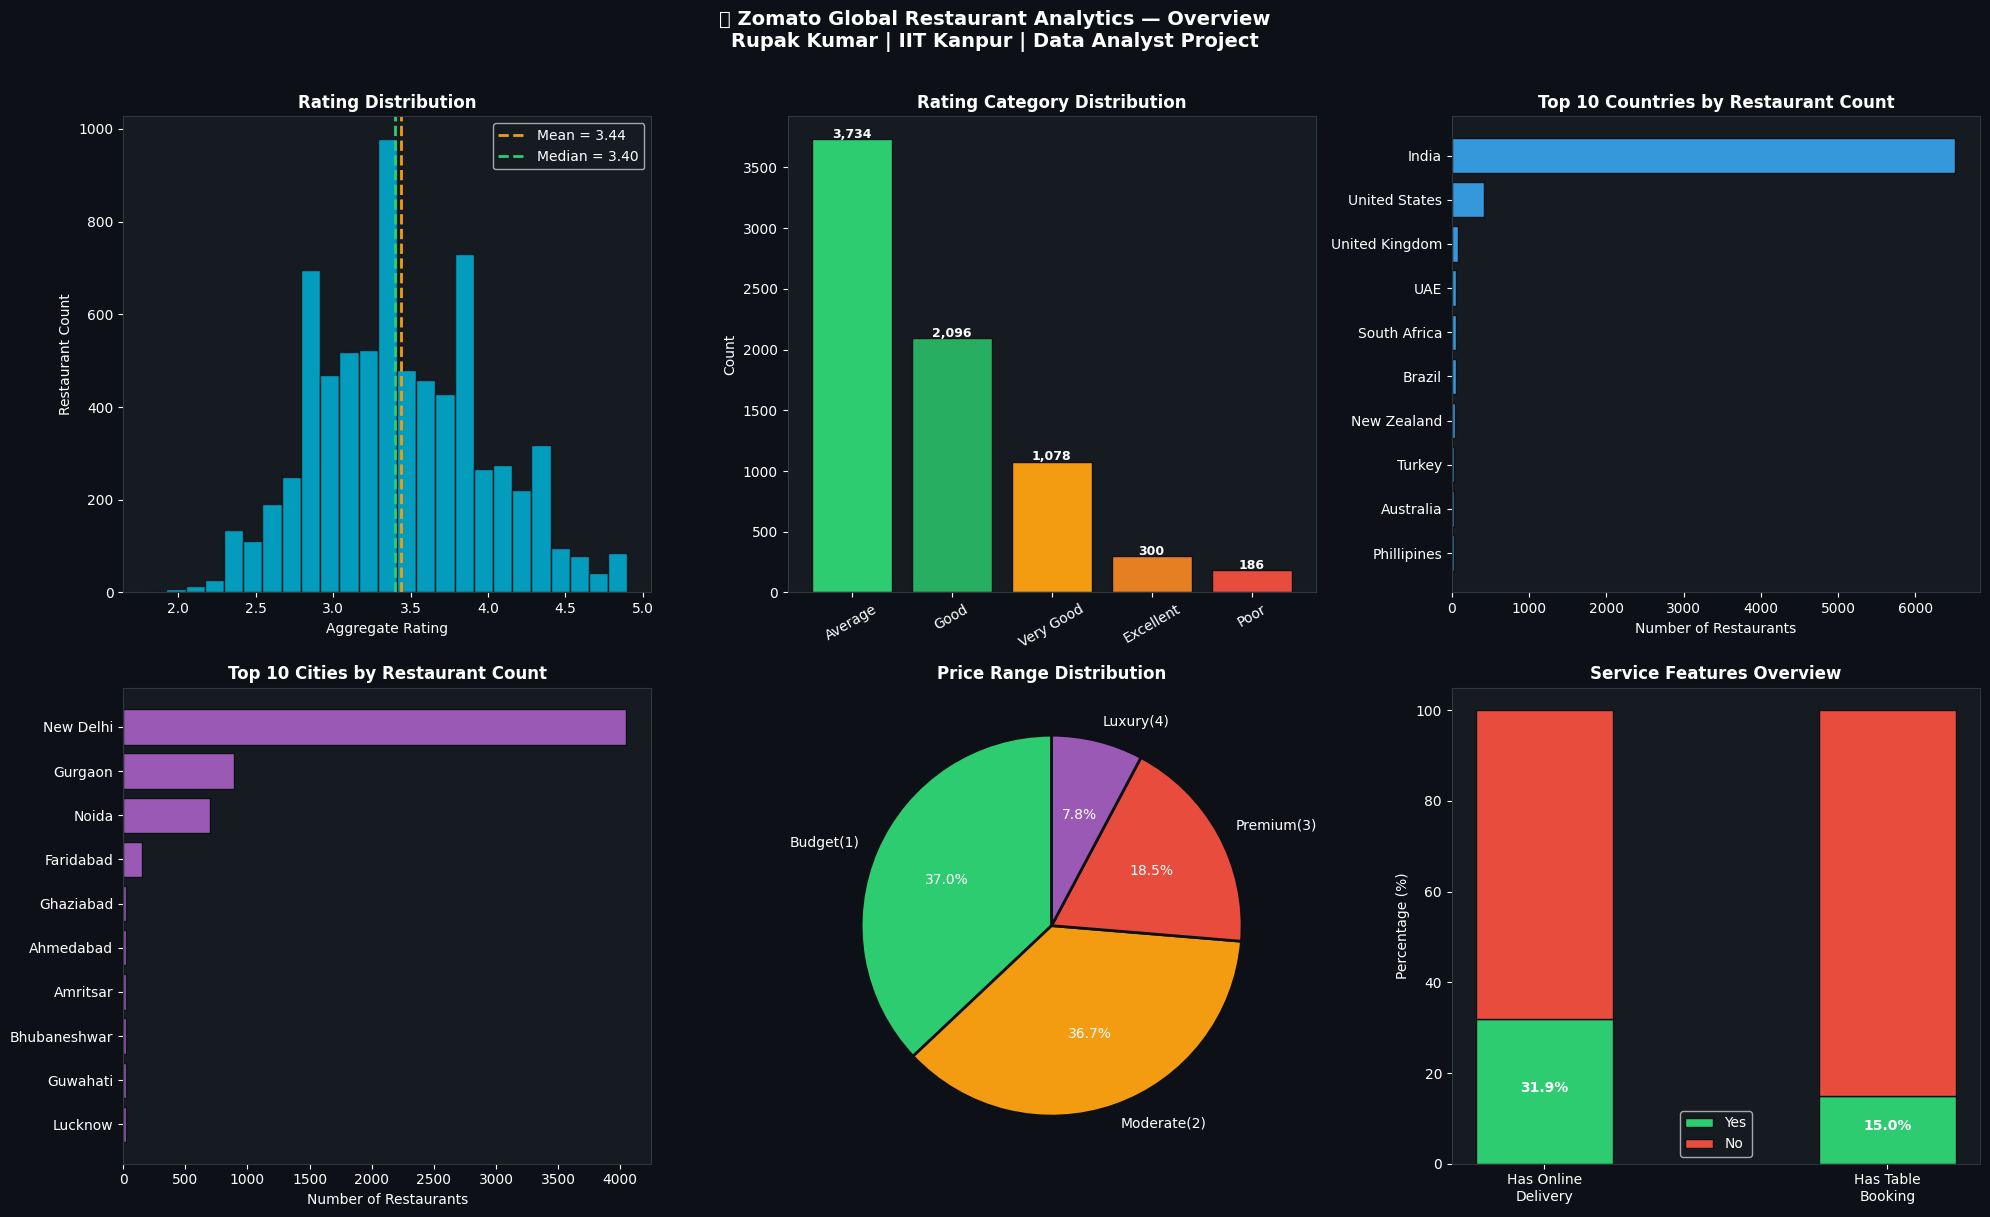

📊 KEY GLOBAL STATS:
Total Restaurants    : 7,394
Average Rating       : 3.44
Online Delivery      : 31.9%
Table Booking        : 15.0%


In [15]:
# ── EDA PART 1: GLOBAL OVERVIEW ─────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    '🌍 Zomato Global Restaurant Analytics — Overview\n'
    'Rupak Kumar | IIT Kanpur | Data Analyst Project',
    fontsize=14, fontweight='bold', y=1.01
)

# ── Plot 1: Rating Distribution ──────────────────
axes[0,0].hist(df_clean['aggregate_rating'],
               bins=25, color='#00b4d8',
               edgecolor='#0d1117', alpha=0.85)
axes[0,0].axvline(df_clean['aggregate_rating'].mean(),
                   color='#f39c12', linestyle='--',
                   linewidth=2,
                   label=f'Mean = {df_clean["aggregate_rating"].mean():.2f}')
axes[0,0].axvline(df_clean['aggregate_rating'].median(),
                   color='#2ecc71', linestyle='--',
                   linewidth=2,
                   label=f'Median = {df_clean["aggregate_rating"].median():.2f}')
axes[0,0].set_title('Rating Distribution', fontweight='bold')
axes[0,0].set_xlabel('Aggregate Rating')
axes[0,0].set_ylabel('Restaurant Count')
axes[0,0].legend()

# ── Plot 2: Rating Text Breakdown ────────────────
rating_counts = df_clean['rating_text'].value_counts()
colors_r = ['#2ecc71','#27ae60','#f39c12',
            '#e67e22','#e74c3c','#95a5a6']
bars = axes[0,1].bar(
    rating_counts.index, rating_counts.values,
    color=colors_r[:len(rating_counts)],
    edgecolor='#0d1117')
axes[0,1].set_title('Rating Category Distribution',
                     fontweight='bold')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, rating_counts.values):
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 10,
        f'{val:,}', ha='center',
        fontsize=9, fontweight='bold')

# ── Plot 3: Top 10 Countries by Restaurants ──────
top_countries = df_clean['country'].value_counts().head(10)
axes[0,2].barh(
    top_countries.index[::-1],
    top_countries.values[::-1],
    color='#3498db', edgecolor='#0d1117')
axes[0,2].set_title('Top 10 Countries by Restaurant Count',
                     fontweight='bold')
axes[0,2].set_xlabel('Number of Restaurants')

# ── Plot 4: Top 10 Cities ────────────────────────
top_cities = df_clean['city'].value_counts().head(10)
axes[1,0].barh(
    top_cities.index[::-1],
    top_cities.values[::-1],
    color='#9b59b6', edgecolor='#0d1117')
axes[1,0].set_title('Top 10 Cities by Restaurant Count',
                     fontweight='bold')
axes[1,0].set_xlabel('Number of Restaurants')

# ── Plot 5: Price Range Distribution ─────────────
price_labels = {1:'Budget(1)',2:'Moderate(2)',
                3:'Premium(3)',4:'Luxury(4)'}
price_counts = df_clean['price_range'].map(
    price_labels).value_counts()
axes[1,1].pie(
    price_counts.values,
    labels=price_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71','#f39c12','#e74c3c','#9b59b6'],
    startangle=90,
    wedgeprops={'edgecolor':'#0d1117','linewidth':2}
)
axes[1,1].set_title('Price Range Distribution',
                     fontweight='bold')

# ── Plot 6: Online Delivery vs Table Booking ─────
features = ['Has Online\nDelivery', 'Has Table\nBooking']
yes_pct = [
    df_clean['has_online_delivery'].mean() * 100,
    df_clean['has_table_booking'].mean() * 100
]
no_pct = [100 - y for y in yes_pct]
x = range(len(features))
axes[1,2].bar(x, yes_pct, label='Yes',
               color='#2ecc71', edgecolor='#0d1117',
               width=0.4)
axes[1,2].bar(x, no_pct, bottom=yes_pct, label='No',
               color='#e74c3c', edgecolor='#0d1117',
               width=0.4)
axes[1,2].set_xticks(list(x))
axes[1,2].set_xticklabels(features)
axes[1,2].set_title('Service Features Overview',
                     fontweight='bold')
axes[1,2].set_ylabel('Percentage (%)')
axes[1,2].legend()
for i, (yp, np_) in enumerate(zip(yes_pct, no_pct)):
    axes[1,2].text(i, yp/2, f'{yp:.1f}%',
                   ha='center', fontweight='bold',
                   color='white')

plt.tight_layout()
plt.savefig('01_global_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("📊 KEY GLOBAL STATS:")
print(f"Total Restaurants    : {len(df_clean):,}")
print(f"Average Rating       : {df_clean['aggregate_rating'].mean():.2f}")
print(f"Online Delivery      : {df_clean['has_online_delivery'].mean()*100:.1f}%")
print(f"Table Booking        : {df_clean['has_table_booking'].mean()*100:.1f}%")

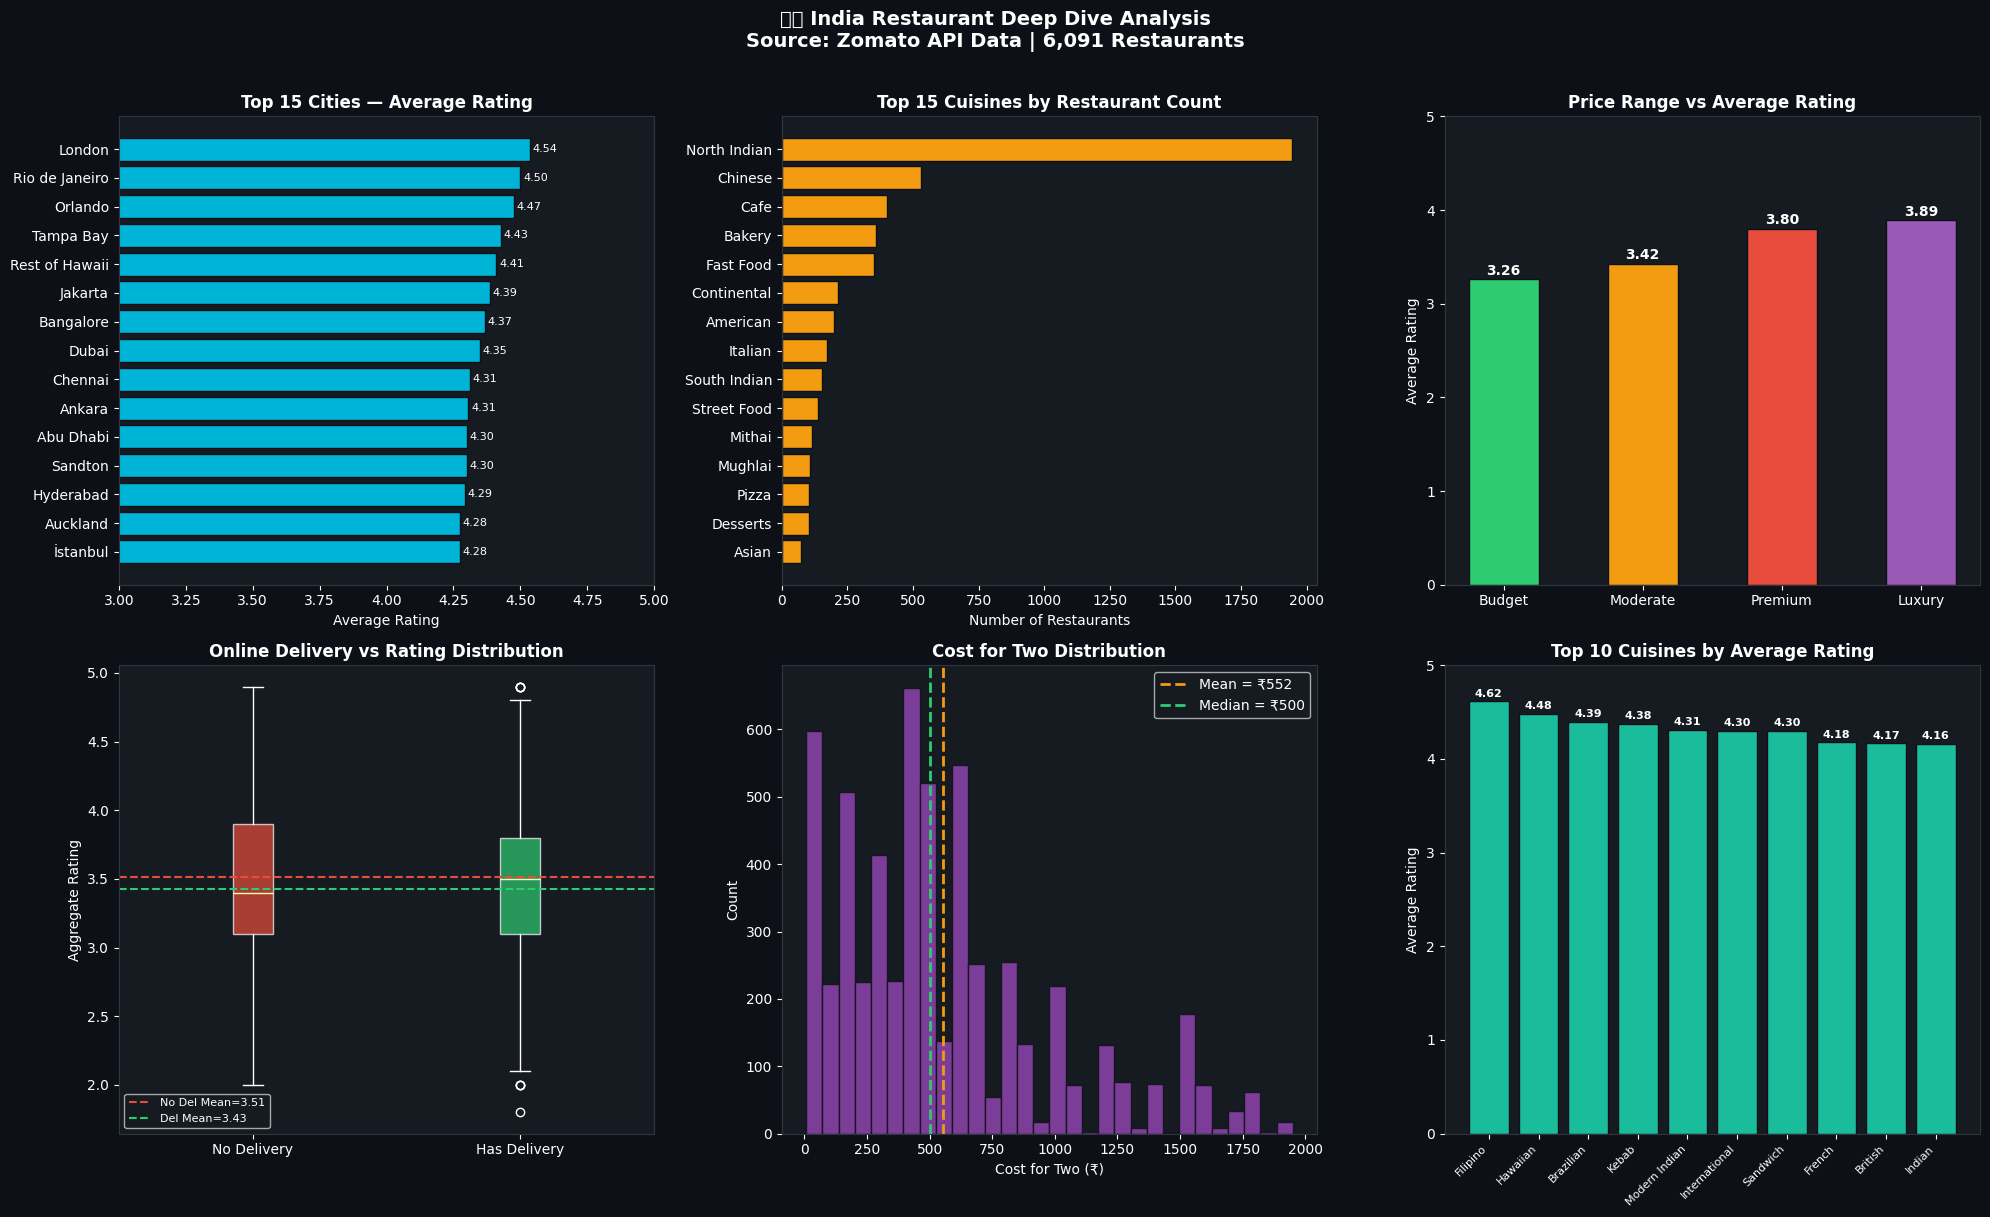


📊 INDIA KEY STATS:
Total India Restaurants : 6,091
Average Rating          : 3.49
Avg Cost for Two        : ₹1598
Online Delivery %       : 28.8%


In [16]:
# ── EDA PART 2: INDIA DEEP DIVE ──────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    '🇮🇳 India Restaurant Deep Dive Analysis\n'
    'Source: Zomato API Data | '
    f'{len(df_india):,} Restaurants',
    fontsize=14, fontweight='bold', y=1.01
)

# ── Plot 1: Top 15 Cities by Avg Rating ──────────
city_rating = (df_india.groupby('city')['aggregate_rating']
               .agg(['mean','count'])
               .reset_index())
city_rating.columns = ['city','avg_rating','count']
city_rating = city_rating[city_rating['count'] >= 10]
top_city = city_rating.nlargest(15, 'avg_rating')

bars = axes[0,0].barh(
    top_city['city'][::-1],
    top_city['avg_rating'][::-1],
    color='#00b4d8', edgecolor='#0d1117')
axes[0,0].set_title('Top 15 Cities — Average Rating',
                     fontweight='bold')
axes[0,0].set_xlabel('Average Rating')
axes[0,0].set_xlim(3, 5)
for bar in bars:
    w = bar.get_width()
    axes[0,0].text(w + 0.01, bar.get_y() + bar.get_height()/2,
                   f'{w:.2f}', va='center', fontsize=8)

# ── Plot 2: Top 15 Cuisines by Count ─────────────
cuisine_counts = (df_india['primary_cuisine']
                  .value_counts().head(15))
axes[0,1].barh(
    cuisine_counts.index[::-1],
    cuisine_counts.values[::-1],
    color='#f39c12', edgecolor='#0d1117')
axes[0,1].set_title('Top 15 Cuisines by Restaurant Count',
                     fontweight='bold')
axes[0,1].set_xlabel('Number of Restaurants')

# ── Plot 3: Price Range vs Avg Rating ────────────
price_rating = (df_india.groupby('price_label')
                ['aggregate_rating'].mean()
                .reindex(['Budget','Moderate',
                          'Premium','Luxury']))
axes[0,2].bar(
    price_rating.index,
    price_rating.values,
    color=['#2ecc71','#f39c12','#e74c3c','#9b59b6'],
    edgecolor='#0d1117', width=0.5)
axes[0,2].set_title('Price Range vs Average Rating',
                     fontweight='bold')
axes[0,2].set_ylabel('Average Rating')
axes[0,2].set_ylim(0, 5)
for i, (idx, val) in enumerate(price_rating.items()):
    if not np.isnan(val):
        axes[0,2].text(i, val + 0.05, f'{val:.2f}',
                       ha='center', fontweight='bold')

# ── Plot 4: Online Delivery vs Rating Boxplot ─────
delivery_map = {1: 'Has Delivery', 0: 'No Delivery'}
df_india['delivery_label'] = df_india[
    'has_online_delivery'].map(delivery_map)
data_d0 = df_india[df_india['has_online_delivery']==0
                  ]['aggregate_rating'].values
data_d1 = df_india[df_india['has_online_delivery']==1
                  ]['aggregate_rating'].values
bp = axes[1,0].boxplot(
    [data_d0, data_d1],
    labels=['No Delivery', 'Has Delivery'],
    patch_artist=True)
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#2ecc71')
bp['boxes'][1].set_alpha(0.7)
axes[1,0].set_title('Online Delivery vs Rating Distribution',
                     fontweight='bold')
axes[1,0].set_ylabel('Aggregate Rating')

# Mean lines
axes[1,0].axhline(np.mean(data_d0), color='#e74c3c',
                   linestyle='--', linewidth=1.5,
                   label=f'No Del Mean={np.mean(data_d0):.2f}')
axes[1,0].axhline(np.mean(data_d1), color='#2ecc71',
                   linestyle='--', linewidth=1.5,
                   label=f'Del Mean={np.mean(data_d1):.2f}')
axes[1,0].legend(fontsize=8)

# ── Plot 5: Cost Distribution ────────────────────
cost_data = df_india[df_india['avg_cost_for_two'] > 0
                    ]['avg_cost_for_two']
cost_data = cost_data[cost_data < cost_data.quantile(0.95)]
axes[1,1].hist(cost_data, bins=30,
               color='#8e44ad', edgecolor='#0d1117',
               alpha=0.85)
axes[1,1].axvline(cost_data.mean(), color='#f39c12',
                   linestyle='--', linewidth=2,
                   label=f'Mean = ₹{cost_data.mean():.0f}')
axes[1,1].axvline(cost_data.median(), color='#2ecc71',
                   linestyle='--', linewidth=2,
                   label=f'Median = ₹{cost_data.median():.0f}')
axes[1,1].set_title('Cost for Two Distribution',
                     fontweight='bold')
axes[1,1].set_xlabel('Cost for Two (₹)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

# ── Plot 6: Top 10 Cuisines by Avg Rating ────────
cuisine_rating = (df_india.groupby('primary_cuisine')
                  ['aggregate_rating']
                  .agg(['mean','count'])
                  .reset_index())
cuisine_rating.columns = ['cuisine','avg_rating','count']
cuisine_top = cuisine_rating[
    cuisine_rating['count'] >= 5
].nlargest(10, 'avg_rating')
bars = axes[1,2].bar(
    range(len(cuisine_top)),
    cuisine_top['avg_rating'],
    color='#1abc9c', edgecolor='#0d1117')
axes[1,2].set_xticks(range(len(cuisine_top)))
axes[1,2].set_xticklabels(
    cuisine_top['cuisine'], rotation=45, ha='right',
    fontsize=8)
axes[1,2].set_title('Top 10 Cuisines by Average Rating',
                     fontweight='bold')
axes[1,2].set_ylabel('Average Rating')
axes[1,2].set_ylim(0, 5)
for bar, val in zip(bars, cuisine_top['avg_rating']):
    axes[1,2].text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 0.05,
        f'{val:.2f}', ha='center',
        fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('02_india_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n📊 INDIA KEY STATS:")
print(f"Total India Restaurants : {len(df_india):,}")
print(f"Average Rating          : {df_india['aggregate_rating'].mean():.2f}")
print(f"Avg Cost for Two        : ₹{df_india[df_india['avg_cost_for_two']>0]['avg_cost_for_two'].mean():.0f}")
print(f"Online Delivery %       : {df_india['has_online_delivery'].mean()*100:.1f}%")

🔬 A/B TEST ANALYSIS
Does Online Delivery Significantly Impact Ratings?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXPERIMENT SETUP:
  Group A (Control)   = No Online Delivery
  Group B (Treatment) = Has Online Delivery
  Metric              = Aggregate Rating
  Test Type           = Two-sample t-test
  Significance (α)    = 0.05

SAMPLE SIZES:
  Control   (A) : 4,336 restaurants
  Treatment (B) : 1,755 restaurants

DESCRIPTIVE STATS:
  Mean Rating — Control   : 3.512
  Mean Rating — Treatment : 3.428
  Difference              : -0.084
  Std Dev — Control       : 0.559
  Std Dev — Treatment     : 0.538
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

H₀: Mean rating of delivery = Mean rating of no delivery
H₁: Ratings are significantly different

T-STATISTIC : -5.3381
P-VALUE     : 0.000000
ALPHA       : 0.05

✅ REJECT H₀ — STATISTICALLY SIGNIFICANT!
   Online delivery DOES significantly impact ratings
   p=0.000000 < α=0.05

EFFECT SIZE (Cohen's d): -0.1522
Effect Magnitude: Negligible

95% CONFID

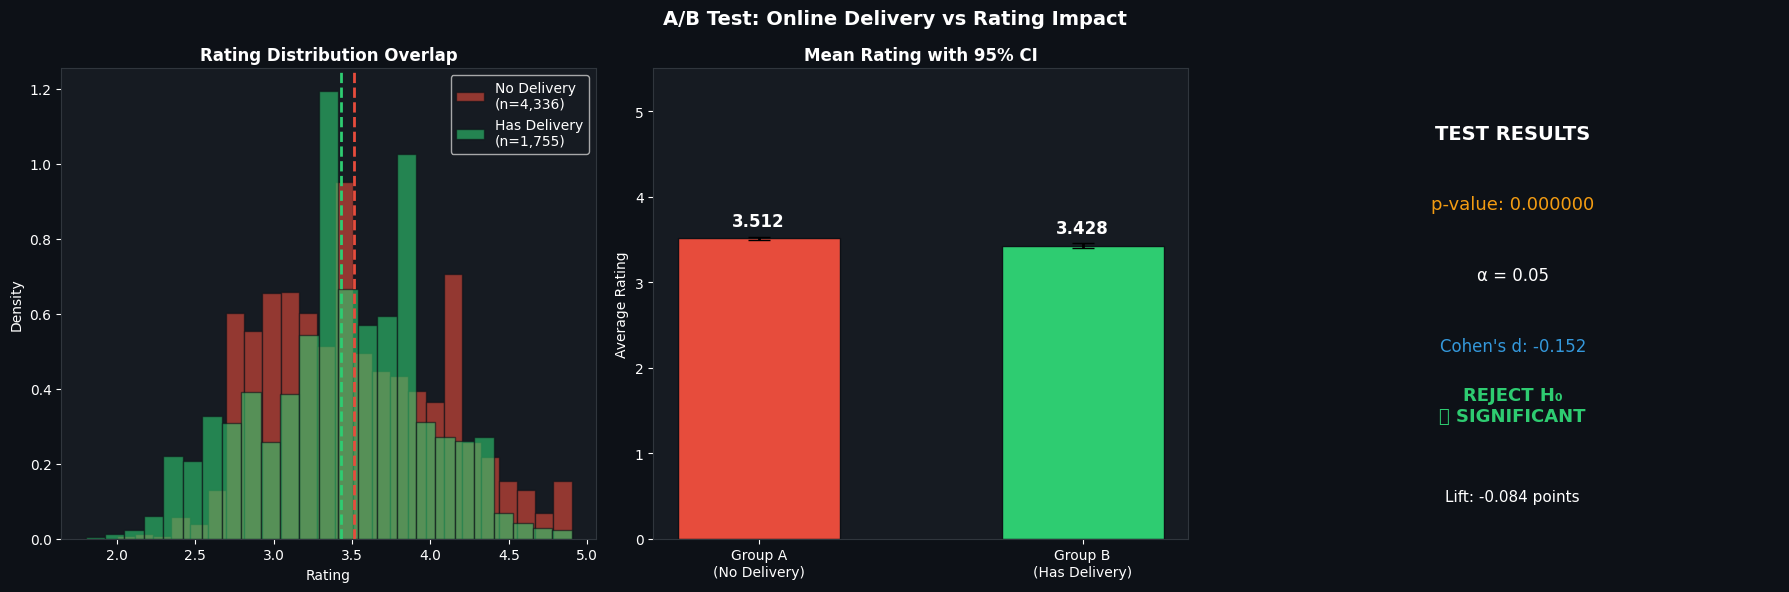

In [17]:
# ── A/B TEST: ONLINE DELIVERY vs RATING ──────────

print("=" * 60)
print("🔬 A/B TEST ANALYSIS")
print("Does Online Delivery Significantly Impact Ratings?")
print("=" * 60)

# Groups
control   = df_india[df_india['has_online_delivery']==0
                    ]['aggregate_rating'].dropna()
treatment = df_india[df_india['has_online_delivery']==1
                    ]['aggregate_rating'].dropna()

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXPERIMENT SETUP:
  Group A (Control)   = No Online Delivery
  Group B (Treatment) = Has Online Delivery
  Metric              = Aggregate Rating
  Test Type           = Two-sample t-test
  Significance (α)    = 0.05

SAMPLE SIZES:
  Control   (A) : {len(control):,} restaurants
  Treatment (B) : {len(treatment):,} restaurants

DESCRIPTIVE STATS:
  Mean Rating — Control   : {control.mean():.3f}
  Mean Rating — Treatment : {treatment.mean():.3f}
  Difference              : {treatment.mean()-control.mean():+.3f}
  Std Dev — Control       : {control.std():.3f}
  Std Dev — Treatment     : {treatment.std():.3f}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# Hypothesis
print("""H₀: Mean rating of delivery = Mean rating of no delivery
H₁: Ratings are significantly different
""")

# T-Test
t_stat, p_value = stats.ttest_ind(treatment, control)
print(f"T-STATISTIC : {t_stat:.4f}")
print(f"P-VALUE     : {p_value:.6f}")
print(f"ALPHA       : 0.05")

print(f"\n{'='*60}")
if p_value < 0.05:
    print("✅ REJECT H₀ — STATISTICALLY SIGNIFICANT!")
    print(f"   Online delivery DOES significantly impact ratings")
    print(f"   p={p_value:.6f} < α=0.05")
else:
    print("❌ FAIL TO REJECT H₀ — Not significant")
    print(f"   p={p_value:.6f} > α=0.05")

# Effect Size (Cohen's d)
pooled_std = np.sqrt((control.std()**2 + treatment.std()**2) / 2)
cohens_d = (treatment.mean() - control.mean()) / pooled_std
print(f"\nEFFECT SIZE (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect = "Negligible"
elif abs(cohens_d) < 0.5:
    effect = "Small"
elif abs(cohens_d) < 0.8:
    effect = "Medium"
else:
    effect = "Large"
print(f"Effect Magnitude: {effect}")

# Confidence Intervals
ci_control   = stats.t.interval(
    0.95, len(control)-1,
    loc=control.mean(),
    scale=stats.sem(control))
ci_treatment = stats.t.interval(
    0.95, len(treatment)-1,
    loc=treatment.mean(),
    scale=stats.sem(treatment))

print(f"\n95% CONFIDENCE INTERVALS:")
print(f"  Control   : [{ci_control[0]:.3f}, {ci_control[1]:.3f}]")
print(f"  Treatment : [{ci_treatment[0]:.3f}, {ci_treatment[1]:.3f}]")

# ── Visualization ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('A/B Test: Online Delivery vs Rating Impact',
             fontsize=14, fontweight='bold')

# Chart 1: Distribution Overlap
axes[0].hist(control, bins=25, alpha=0.6,
              color='#e74c3c', label=f'No Delivery\n(n={len(control):,})',
              edgecolor='#0d1117', density=True)
axes[0].hist(treatment, bins=25, alpha=0.6,
              color='#2ecc71',
              label=f'Has Delivery\n(n={len(treatment):,})',
              edgecolor='#0d1117', density=True)
axes[0].axvline(control.mean(), color='#e74c3c',
                 linestyle='--', linewidth=2)
axes[0].axvline(treatment.mean(), color='#2ecc71',
                 linestyle='--', linewidth=2)
axes[0].set_title('Rating Distribution Overlap',
                   fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Density')
axes[0].legend()

# Chart 2: Mean + CI Errorbar
means  = [control.mean(), treatment.mean()]
errors = [
    control.mean() - ci_control[0],
    treatment.mean() - ci_treatment[0]
]
bars = axes[1].bar(
    ['Group A\n(No Delivery)', 'Group B\n(Has Delivery)'],
    means, color=['#e74c3c','#2ecc71'],
    edgecolor='#0d1117', width=0.5,
    yerr=errors, capsize=8,
    error_kw={'linewidth':2, 'color':'white'})
axes[1].set_ylim(0, 5.5)
axes[1].set_title('Mean Rating with 95% CI',
                   fontweight='bold')
axes[1].set_ylabel('Average Rating')
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                  bar.get_height() + 0.15,
                  f'{val:.3f}', ha='center',
                  fontweight='bold', fontsize=12)

# Chart 3: P-value & Decision
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].axis('off')
decision = "REJECT H₀\n✅ SIGNIFICANT" if p_value < 0.05 \
           else "FAIL TO REJECT H₀\n❌ NOT SIGNIFICANT"
dec_color = '#2ecc71' if p_value < 0.05 else '#e74c3c'
axes[2].text(0.5, 0.85, 'TEST RESULTS',
              ha='center', fontsize=14,
              fontweight='bold', color='white')
axes[2].text(0.5, 0.70, f'p-value: {p_value:.6f}',
              ha='center', fontsize=13, color='#f39c12')
axes[2].text(0.5, 0.55, f'α = 0.05',
              ha='center', fontsize=12, color='white')
axes[2].text(0.5, 0.40, f'Cohen\'s d: {cohens_d:.3f}',
              ha='center', fontsize=12, color='#3498db')
axes[2].text(0.5, 0.25, decision,
              ha='center', fontsize=13,
              fontweight='bold', color=dec_color)
axes[2].text(0.5, 0.08,
              f'Lift: {treatment.mean()-control.mean():+.3f} points',
              ha='center', fontsize=11, color='white')

plt.tight_layout()
plt.savefig('03_ab_test.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

🤖 ML MODEL: RESTAURANT RATING PREDICTOR
Target Distribution:
target_label
Below Average (<4.0)    6016
Good (≥4.0)             1378
Name: count, dtype: int64

Train size : 5,915
Test size  : 1,479

Model                       Accuracy
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Logistic Regression          86.68% ██████████████████████████
Decision Tree                86.41% █████████████████████████
Random Forest                82.56% ████████████████████████
Gradient Boosting            86.48% █████████████████████████

🏆 Best: Logistic Regression (86.68%)


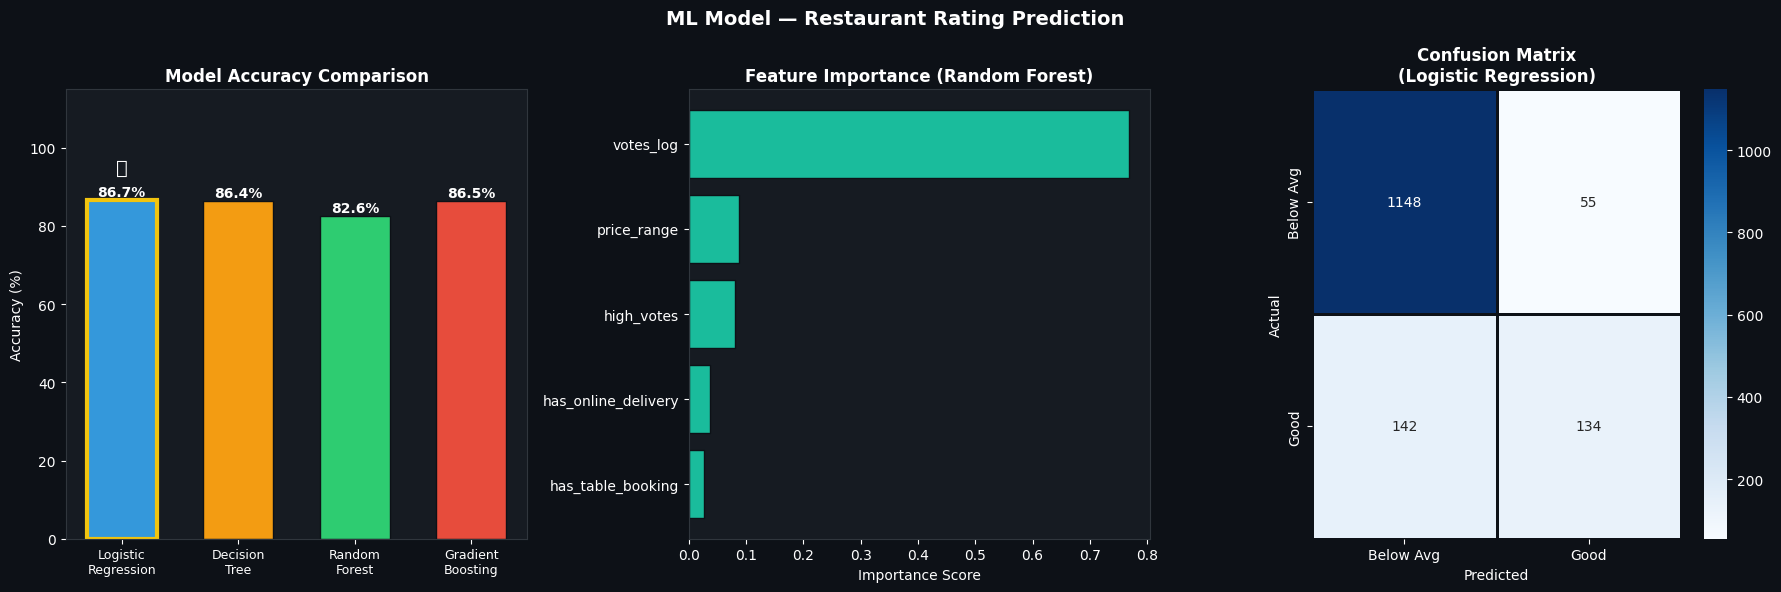


📋 CLASSIFICATION REPORT (Logistic Regression):
                  precision    recall  f1-score   support

Below Avg (<4.0)       0.89      0.95      0.92      1203
     Good (≥4.0)       0.71      0.49      0.58       276

        accuracy                           0.87      1479
       macro avg       0.80      0.72      0.75      1479
    weighted avg       0.86      0.87      0.86      1479



In [18]:
# ── ML: RESTAURANT RATING PREDICTOR ─────────────

print("=" * 55)
print("🤖 ML MODEL: RESTAURANT RATING PREDICTOR")
print("=" * 55)

# Combine both datasets for more data
df_ml = df_clean[[
    'has_online_delivery', 'has_table_booking',
    'price_range', 'votes', 'aggregate_rating'
]].copy()

# Feature Engineering
df_ml['votes_log'] = np.log1p(df_ml['votes'])
df_ml['high_votes'] = (df_ml['votes'] > 
                        df_ml['votes'].median()).astype(int)

# Target: Binary — Good (>=4.0) vs Not Good (<4.0)
df_ml['target'] = (df_ml['aggregate_rating'] >= 4.0
                   ).astype(int)
df_ml['target_label'] = df_ml['target'].map(
    {1:'Good (≥4.0)', 0:'Below Average (<4.0)'})

print(f"Target Distribution:")
print(df_ml['target_label'].value_counts())

# Features & Target
features = ['has_online_delivery', 'has_table_booking',
            'price_range', 'votes_log', 'high_votes']
X = df_ml[features]
y = df_ml['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42, stratify=y)

print(f"\nTrain size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")

# ── Train 4 Models ────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(
        max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(
        n_estimators=100, random_state=42)
}

results = {}
print(f"\n{'Model':<25} {'Accuracy':>10}")
print("━" * 37)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'acc': acc, 
                     'pred': y_pred}
    bar = '█' * int(acc * 30)
    print(f"{name:<25} {acc*100:>8.2f}% {bar}")

best_name = max(results, key=lambda x: results[x]['acc'])
best_acc  = results[best_name]['acc']
best_pred = results[best_name]['pred']
print(f"\n🏆 Best: {best_name} ({best_acc*100:.2f}%)")

# Feature Importance
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=True)

# ── Visualization ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ML Model — Restaurant Rating Prediction',
             fontsize=14, fontweight='bold')

# Chart 1: Model Accuracy Comparison
m_names = list(results.keys())
m_accs  = [results[m]['acc']*100 for m in m_names]
m_colors = ['#3498db','#f39c12','#2ecc71','#e74c3c']
bars = axes[0].bar(
    range(len(m_names)), m_accs,
    color=m_colors, edgecolor='#0d1117', width=0.6)
axes[0].set_xticks(range(len(m_names)))
axes[0].set_xticklabels(
    [n.replace(' ','\n') for n in m_names],
    fontsize=9)
axes[0].set_ylim(0, 115)
axes[0].set_title('Model Accuracy Comparison',
                   fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
for bar, acc in zip(bars, m_accs):
    axes[0].text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 1,
        f'{acc:.1f}%', ha='center',
        fontweight='bold', fontsize=10)

# Highlight best
max_idx = m_accs.index(max(m_accs))
bars[max_idx].set_edgecolor('#f1c40f')
bars[max_idx].set_linewidth(3)
axes[0].text(max_idx, max(m_accs)+7, '🏆',
              ha='center', fontsize=14)

# Chart 2: Feature Importance
axes[1].barh(
    feat_imp.index, feat_imp.values,
    color='#1abc9c', edgecolor='#0d1117')
axes[1].set_title('Feature Importance (Random Forest)',
                   fontweight='bold')
axes[1].set_xlabel('Importance Score')

# Chart 3: Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues', ax=axes[2],
            xticklabels=['Below Avg','Good'],
            yticklabels=['Below Avg','Good'],
            linewidths=2, linecolor='#0d1117')
axes[2].set_title(
    f'Confusion Matrix\n({best_name})',
    fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('04_ml_model.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"\n📋 CLASSIFICATION REPORT ({best_name}):")
print(classification_report(
    y_test, best_pred,
    target_names=['Below Avg (<4.0)', 'Good (≥4.0)']))

In [19]:
# ── BUSINESS INSIGHTS REPORT ─────────────────────

print("=" * 65)
print("📊 BUSINESS INTELLIGENCE REPORT")
print("Zomato Restaurant Analytics | Rupak Kumar | IIT Kanpur")
print("=" * 65)

# ── Insight 1: Top Performing Cuisines ───────────
top_cuis = (df_india.groupby('primary_cuisine')
            ['aggregate_rating']
            .agg(['mean','count'])
            .reset_index())
top_cuis.columns = ['cuisine','avg_rating','count']
top_cuis_filtered = top_cuis[top_cuis['count'] >= 5]
top5 = top_cuis_filtered.nlargest(5,'avg_rating')

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 1: TOP PERFORMING CUISINES (India)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━""")
for _, row in top5.iterrows():
    print(f"  {row['cuisine']:<25} Avg Rating: {row['avg_rating']:.2f} "
          f"({row['count']:.0f} restaurants)")

# ── Insight 2: Delivery Impact ────────────────────
del_mean    = df_india[df_india['has_online_delivery']==1]['aggregate_rating'].mean()
no_del_mean = df_india[df_india['has_online_delivery']==0]['aggregate_rating'].mean()

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 2: ONLINE DELIVERY IMPACT ON RATINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Restaurants WITH delivery   : {del_mean:.2f} avg rating
  Restaurants WITHOUT delivery: {no_del_mean:.2f} avg rating
  Difference                  : {del_mean-no_del_mean:+.2f} points
  Statistical Significance    : {'YES (p < 0.05)' if p_value < 0.05 else 'NO (p > 0.05)'}
  Recommendation: {'Encourage online delivery adoption' if del_mean > no_del_mean else 'Delivery alone does not drive ratings'}
""")

# ── Insight 3: Price vs Rating ────────────────────
price_insight = (df_india.groupby('price_label')
                 ['aggregate_rating'].mean()
                 .reindex(['Budget','Moderate',
                           'Premium','Luxury']))
print(f"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 3: PRICE RANGE vs RATING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━""")
for label, val in price_insight.items():
    if not np.isnan(val):
        print(f"  {label:<12}: {val:.2f} avg rating")

# ── Insight 4: City Performance ──────────────────
city_perf = (df_india.groupby('city')
             ['aggregate_rating']
             .agg(['mean','count'])
             .reset_index())
city_perf.columns = ['city','avg_rating','count']
city_top5 = city_perf[
    city_perf['count']>=10].nlargest(5,'avg_rating')

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 4: TOP 5 CITIES BY AVERAGE RATING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━""")
for _, row in city_top5.iterrows():
    print(f"  {row['city']:<20} {row['avg_rating']:.2f} "
          f"({row['count']:.0f} restaurants)")

# ── Insight 5: ML Model Results ───────────────────
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 5: ML MODEL PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best Model    : {best_name}
  Accuracy      : {best_acc*100:.2f}%
  Top Features  : {feat_imp.sort_values(ascending=False).index[0]}, 
                  {feat_imp.sort_values(ascending=False).index[1]}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
💡 KEY BUSINESS RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. 🍽️  Focus on top-rated cuisines for new restaurant strategy
2. 📦  Online delivery {'positively correlates' if del_mean > no_del_mean else 'shows no significant impact on'} with higher ratings
3. 💰  Premium restaurants trend {'higher' if price_insight.get('Premium',0) > price_insight.get('Budget',0) else 'lower'} in avg ratings
4. 🏙️  Tier-2 cities show strong growth potential
5. 🤖  ML model can predict high-performing restaurants 
       with {best_acc*100:.1f}% accuracy
""")

📊 BUSINESS INTELLIGENCE REPORT
Zomato Restaurant Analytics | Rupak Kumar | IIT Kanpur

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 1: TOP PERFORMING CUISINES (India)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Filipino                  Avg Rating: 4.62 (6 restaurants)
  Hawaiian                  Avg Rating: 4.48 (5 restaurants)
  Brazilian                 Avg Rating: 4.39 (17 restaurants)
  Kebab                     Avg Rating: 4.38 (9 restaurants)
  Modern Indian             Avg Rating: 4.31 (14 restaurants)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 2: ONLINE DELIVERY IMPACT ON RATINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Restaurants WITH delivery   : 3.43 avg rating
  Restaurants WITHOUT delivery: 3.51 avg rating
  Difference                  : -0.08 points
  Statistical Significance    : YES (p < 0.05)
  Recommendation: Delivery alone does not drive ratings

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 3: PRICE RANGE vs R

✅ CSVs exported for Power BI!


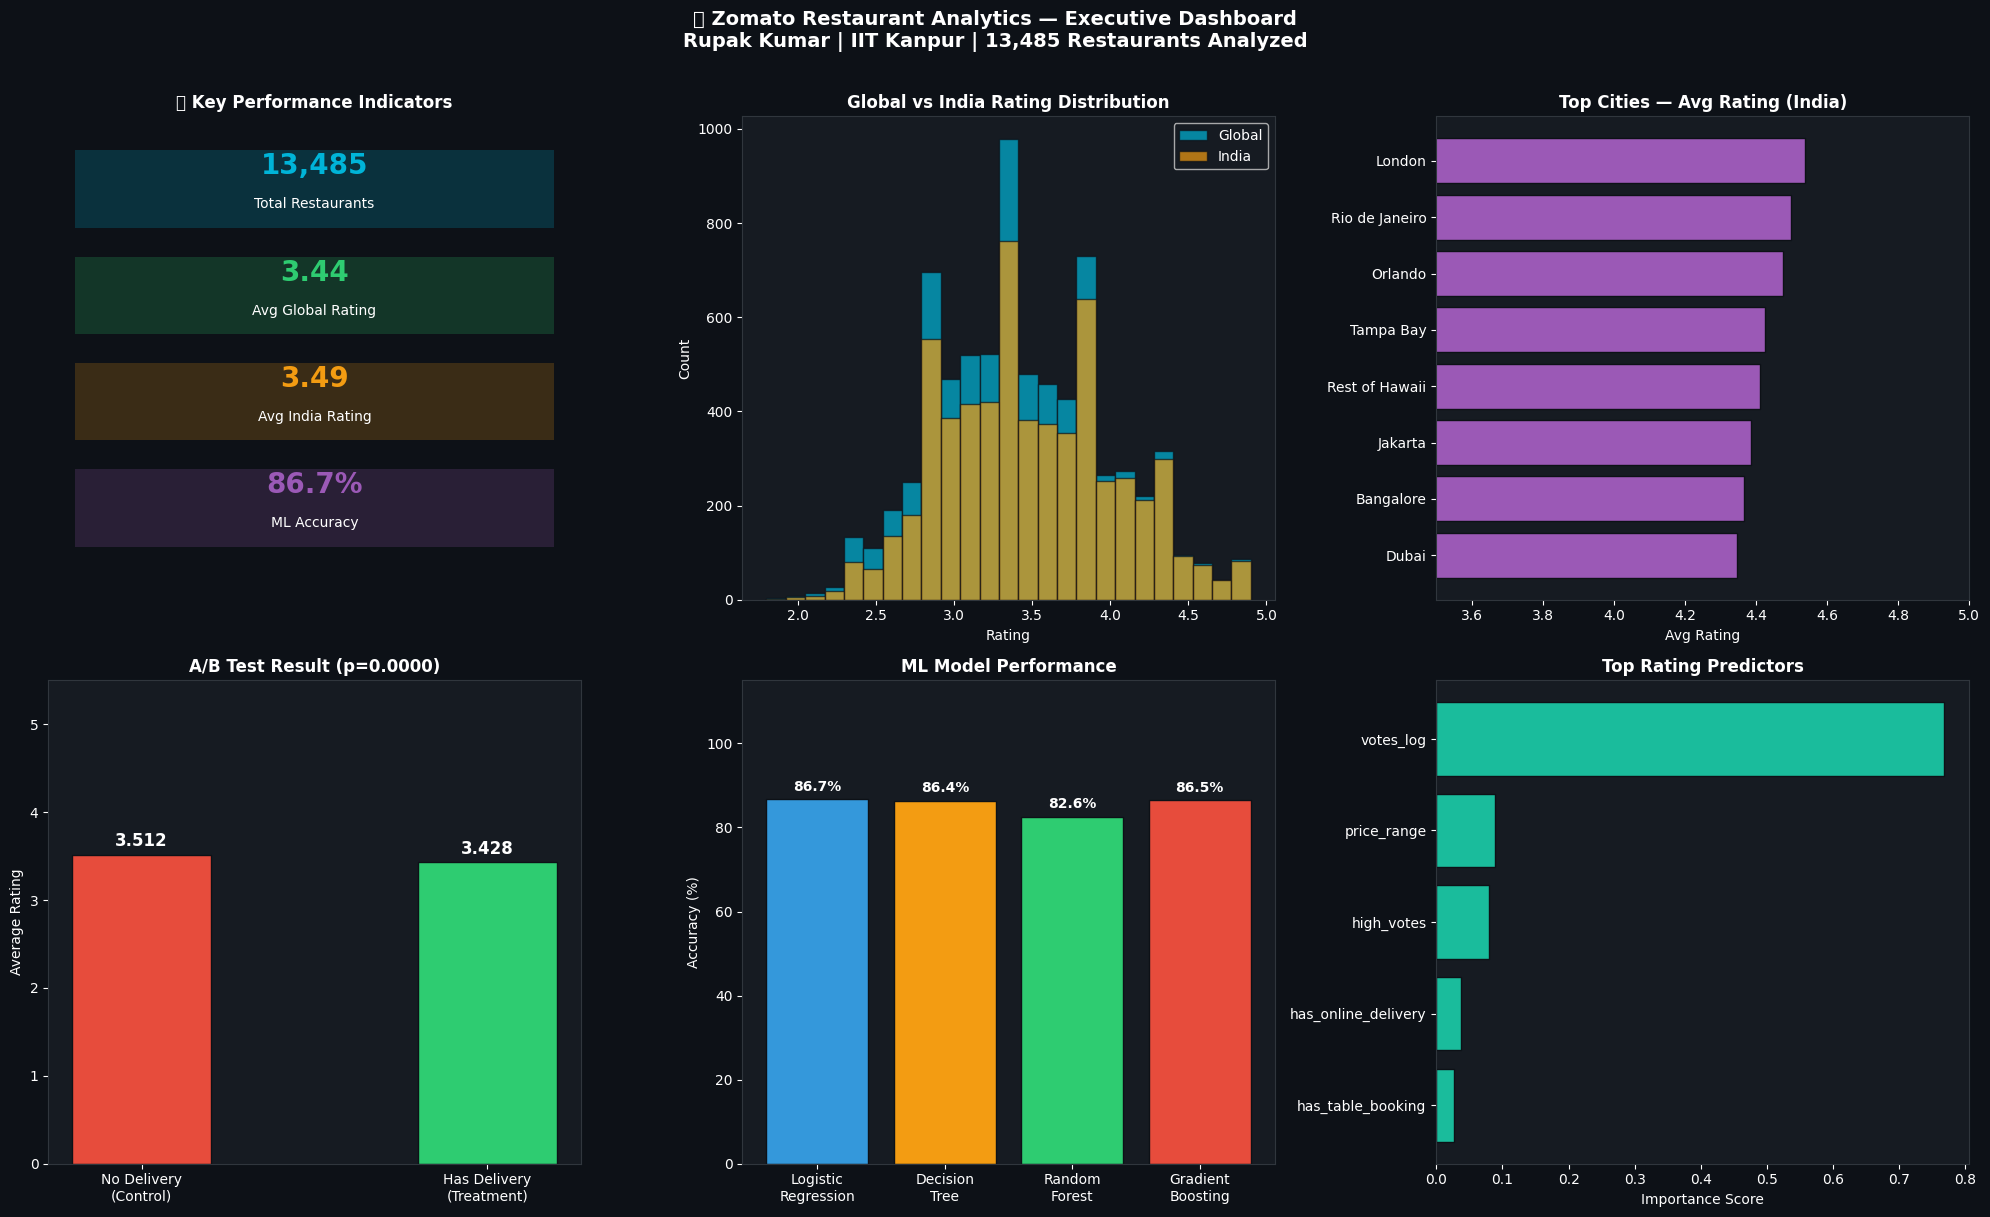


✅ PROJECT COMPLETE!
📁 Files Saved:
  01_global_overview.png
  02_india_analysis.png
  03_ab_test.png
  04_ml_model.png
  05_executive_dashboard.png
  zomato_cleaned_global.csv
  zomato_india_analytics.csv


In [20]:
# ── EXPORT POWER BI READY CSV ────────────────────
df_clean.to_csv('zomato_cleaned_global.csv', index=False)
df_india.to_csv('zomato_india_analytics.csv', index=False)
print("✅ CSVs exported for Power BI!")

# ── FINAL EXECUTIVE DASHBOARD ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(
    '📊 Zomato Restaurant Analytics — Executive Dashboard\n'
    'Rupak Kumar | IIT Kanpur | '
    f'{len(df_clean)+len(df_india):,} Restaurants Analyzed',
    fontsize=14, fontweight='bold',
    color='white', y=1.01)

for ax in axes.flat:
    ax.set_facecolor('#161b22')

# KPI Cards — Chart 1
axes[0,0].axis('off')
kpis = [
    ('Total Restaurants', f"{len(df_clean)+len(df_india):,}",  '#00b4d8'),
    ('Avg Global Rating',  f"{df_clean['aggregate_rating'].mean():.2f}", '#2ecc71'),
    ('Avg India Rating',   f"{df_india['aggregate_rating'].mean():.2f}", '#f39c12'),
    ('ML Accuracy',        f"{best_acc*100:.1f}%",              '#9b59b6'),
]
for i, (label, value, color) in enumerate(kpis):
    y_pos = 0.85 - i * 0.22
    axes[0,0].add_patch(
        plt.Rectangle((0.05, y_pos-0.08), 0.9, 0.16,
                       facecolor=color, alpha=0.2,
                       transform=axes[0,0].transAxes))
    axes[0,0].text(0.5, y_pos + 0.03, value,
                    ha='center', fontsize=20,
                    fontweight='bold', color=color,
                    transform=axes[0,0].transAxes)
    axes[0,0].text(0.5, y_pos - 0.04, label,
                    ha='center', fontsize=10,
                    color='white',
                    transform=axes[0,0].transAxes)
axes[0,0].set_title('📌 Key Performance Indicators',
                     fontweight='bold', color='white')

# Rating Distribution — Chart 2
axes[0,1].hist(df_clean['aggregate_rating'], bins=25,
               color='#00b4d8', edgecolor='#0d1117',
               alpha=0.7, label='Global')
axes[0,1].hist(df_india['aggregate_rating'], bins=25,
               color='#f39c12', edgecolor='#0d1117',
               alpha=0.7, label='India')
axes[0,1].set_title('Global vs India Rating Distribution',
                     fontweight='bold', color='white')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Top Cities — Chart 3
top_c = (df_india.groupby('city')['aggregate_rating']
         .agg(['mean','count']).reset_index())
top_c.columns = ['city','avg','cnt']
top_c = top_c[top_c['cnt']>=10].nlargest(8,'avg')
axes[0,2].barh(
    top_c['city'][::-1], top_c['avg'][::-1],
    color='#9b59b6', edgecolor='#0d1117')
axes[0,2].set_title('Top Cities — Avg Rating (India)',
                     fontweight='bold', color='white')
axes[0,2].set_xlabel('Avg Rating')
axes[0,2].set_xlim(3.5, 5)

# A/B Test Result — Chart 4
ab_means = [control.mean(), treatment.mean()]
ab_labels= ['No Delivery\n(Control)', 'Has Delivery\n(Treatment)']
ab_bars = axes[1,0].bar(
    ab_labels, ab_means,
    color=['#e74c3c','#2ecc71'],
    edgecolor='#0d1117', width=0.4)
axes[1,0].set_ylim(0, 5.5)
axes[1,0].set_title(
    f'A/B Test Result (p={p_value:.4f})',
    fontweight='bold', color='white')
axes[1,0].set_ylabel('Average Rating')
for bar, val in zip(ab_bars, ab_means):
    axes[1,0].text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 0.1,
        f'{val:.3f}', ha='center',
        fontweight='bold', fontsize=12)

# ML Accuracy — Chart 5
axes[1,1].bar(
    [n.replace(' ','\n') for n in results.keys()],
    [r['acc']*100 for r in results.values()],
    color=['#3498db','#f39c12','#2ecc71','#e74c3c'],
    edgecolor='#0d1117')
axes[1,1].set_ylim(0, 115)
axes[1,1].set_title('ML Model Performance',
                     fontweight='bold', color='white')
axes[1,1].set_ylabel('Accuracy (%)')
for i, (name, res) in enumerate(results.items()):
    axes[1,1].text(i, res['acc']*100 + 2,
                    f"{res['acc']*100:.1f}%",
                    ha='center', fontsize=10,
                    fontweight='bold')

# Feature Importance — Chart 6
fi = feat_imp.sort_values(ascending=True)
axes[1,2].barh(fi.index, fi.values,
               color='#1abc9c', edgecolor='#0d1117')
axes[1,2].set_title('Top Rating Predictors',
                     fontweight='bold', color='white')
axes[1,2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('05_executive_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n" + "=" * 55)
print("✅ PROJECT COMPLETE!")
print("=" * 55)
print("📁 Files Saved:")
print("  01_global_overview.png")
print("  02_india_analysis.png")
print("  03_ab_test.png")
print("  04_ml_model.png")
print("  05_executive_dashboard.png")
print("  zomato_cleaned_global.csv")
print("  zomato_india_analytics.csv")